In [5]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


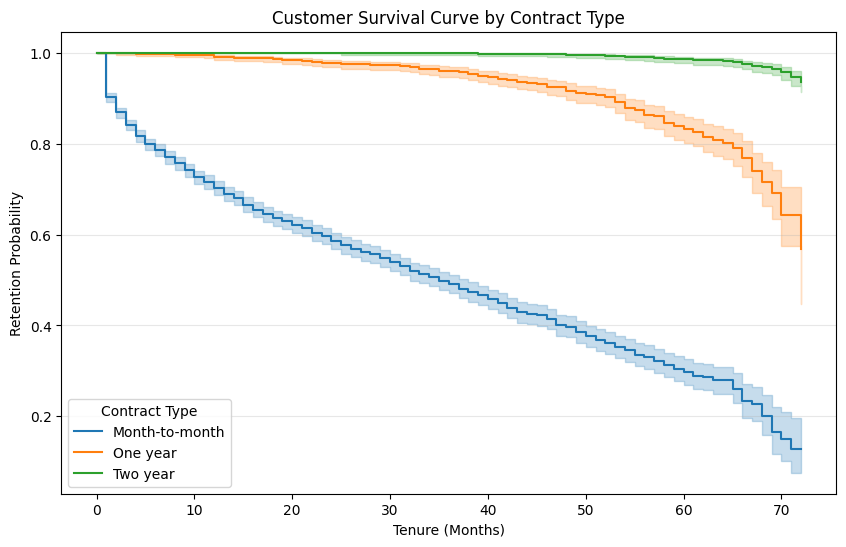

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1. Data Cleaning
# Convert TotalCharges to numeric, handling potential empty strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Convert Churn column to numeric (1 for Yes, 0 for No) for the model
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Survival Analysis Initialization
kmf = KaplanMeierFitter()

# 3. Visualization Setup
plt.figure(figsize=(10, 6))

# 4. Fit and Plot Survival Curves by Contract Type
# We compare: Month-to-month, One year, and Two year contracts
for name, grouped in df.groupby('Contract'):
    kmf.fit(grouped['tenure'], grouped['Churn_Numeric'], label=name)
    kmf.plot_survival_function()

# 5. Chart Formatting
plt.title("Customer Survival Curve by Contract Type")
plt.xlabel("Tenure (Months)")
plt.ylabel("Retention Probability")
plt.grid(axis='y', alpha=0.3)
plt.legend(title="Contract Type")
plt.show()



In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Feature Selection & Encoding
# Selecting key behavioral and financial columns
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 
            'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']

X = df[features].copy()
y = df['Churn_Numeric']

# Encode categorical variables to numeric for the model
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# 2. Model Training (Random Forest)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Extract Feature Importance
importances = pd.DataFrame({'feature': features, 'importance': rf_model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

# 4. Generate Churn Probability for all customers
df['Churn_Probability'] = rf_model.predict_proba(X)[:, 1]

# Display top factors and high-risk customers
print("Top 5 Factors Driving Churn:")
print(importances.head())
print("\nFirst 5 Customers with Churn Risk:")
print(df[['customerID', 'Churn_Probability']].head())

/var/folders/dy/bwl4khd1341gk39k19tt4zvc0000gn/T/ipykernel_63575/3328719217.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


Top 5 Factors Driving Churn:
           feature  importance
17  MonthlyCharges    0.242908
4           tenure    0.225415
14        Contract    0.080188
16   PaymentMethod    0.060580
8   OnlineSecurity    0.053354

First 5 Customers with Churn Risk:
   customerID  Churn_Probability
0  7590-VHVEG               0.21
1  5575-GNVDE               0.01
2  3668-QPYBK               0.79
3  7795-CFOCW               0.02
4  9237-HQITU               0.88


In [13]:
import pandas as pd

# 1. Prepare the final dataset for Excel modeling
# We include IDs, the key drivers, and the prediction result
modeling_data = df[['customerID', 'gender', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn_Probability']]

# 2. Export to CSV (This will save in your current folder)
modeling_data.to_csv('Telco_Churn_Predictions_Final.csv', index=False)

print("Success! File 'Telco_Churn_Predictions_Final.csv' has been created.")
print("This file contains the churn risk score for each customer.")

Success! File 'Telco_Churn_Predictions_Final.csv' has been created.
This file contains the churn risk score for each customer.
